Exploratory analysis

Which conflict variables carry information about Brent crude returns, at what
lag, in which direction, and with what magnitude?

In [2]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

REPORTS = "results/reports"
FIGURES = "results/figures"
os.makedirs(REPORTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

daily = pd.read_csv("datasets/processed/master_daily.csv", parse_dates=["date"]).set_index("date").sort_index()
weekly = pd.read_csv("datasets/processed/master_weekly.csv", parse_dates=["week_start"]).set_index("week_start").sort_index()
CONFLICT_ONSET = pd.Timestamp("2026-03-16")

Joining the weekly conflict data

ACLED variables are weekly; price and rhetoric are daily. Each is tested at its
own sampling frequency, and the grain of every column is reported so a
forward-filled series is never mistaken for a daily one.

In [4]:
from src.data.loaders import grain_report

weekly_ff = weekly.reindex(daily.index, method="ffill")
df = daily.join(weekly_ff)
grain = grain_report(df)
print(grain.to_string(index=False))
grain.to_csv(f"{REPORTS}/grain_report.csv", index=False)
print()
print("weekly columns are kept at weekly grain for inference below")

                  column  n_rows  n_update_events  change_rate                      grain  se_inflation
             brent_close     382              381        0.997                      daily          1.00
          rhetoric_index     382              381        0.997                      daily          1.00
         tanker_rate_usd     382              381        0.997                      daily          1.00
            acled_events     382               70        0.183 forward-filled (sub-daily)          2.34
        acled_fatalities     382               71        0.186 forward-filled (sub-daily)          2.32
acled_fatalities_revised     382               76        0.199 forward-filled (sub-daily)          2.24
         hormuz_severity     382               43        0.113 forward-filled (sub-daily)          2.98

weekly columns are kept at weekly grain for inference below


In [5]:
DRIVERS = [c for c in ["acled_events", "acled_fatalities", "acled_fatalities_revised",
                       "hormuz_severity", "rhetoric_index", "tanker_rate_usd"]
           if c in df.columns]
df[DRIVERS] = df[DRIVERS].ffill()
df = df.dropna(subset=DRIVERS)
print("drivers:", DRIVERS)
print("rows after dropping the unfilled leading period:", len(df))
print()
print(df[DRIVERS].describe().T.to_string())

drivers: ['acled_events', 'acled_fatalities', 'acled_fatalities_revised', 'hormuz_severity', 'rhetoric_index', 'tanker_rate_usd']
rows after dropping the unfilled leading period: 382

                          count          mean          std         min         25%          50%           75%         max
acled_events              382.0     23.267016    11.174442      9.0000     16.0000     19.00000     24.000000     55.0000
acled_fatalities          382.0     24.513089    27.476424      2.0000      9.0000     13.00000     19.000000    102.0000
acled_fatalities_revised  382.0     34.201571    37.762258      3.0000     13.0000     18.00000     25.000000    146.0000
hormuz_severity           382.0      1.486911     0.995310      0.0000      1.0000      1.00000      2.000000      4.0000
rhetoric_index            382.0      0.181360     0.223064     -0.3224      0.0308      0.15975      0.311775      0.9284
tanker_rate_usd           382.0  31029.959162  6354.115289  20972.6000  25192.9000  

Target

R2 on price levels: 0.3965

  acled_events                       0.1349
  acled_fatalities                   0.5473
  acled_fatalities_revised          -0.3406
  hormuz_severity                    1.0167
  rhetoric_index                    -0.8471
  tanker_rate_usd                   -0.0002


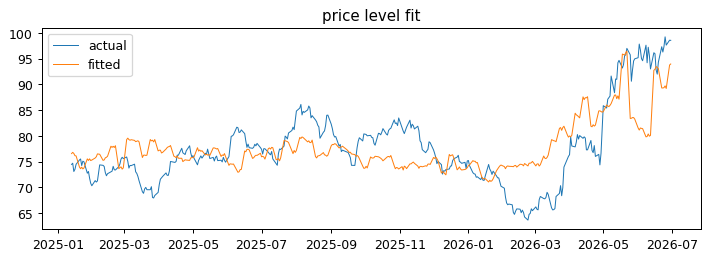

In [7]:
from sklearn.linear_model import LinearRegression

TARGET = "brent_close"
X_lv = df[DRIVERS].ffill().dropna()
y_lv = df.loc[X_lv.index, "brent_close"]
lm = LinearRegression().fit(X_lv, y_lv)
print("R2 on price levels:", round(lm.score(X_lv, y_lv), 4))
print()
for name, coef in zip(X_lv.columns, lm.coef_):
    print(f"  {name:<28} {coef:>12.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(y_lv.index, y_lv, lw=.8, label="actual")
ax.plot(y_lv.index, lm.predict(X_lv), lw=.8, label="fitted")
ax.legend()
ax.set_title("price level fit")
plt.tight_layout()

Correlation matrix

                          acled_events  acled_fatalities  acled_fatalities_revised  hormuz_severity  rhetoric_index  tanker_rate_usd  brent_close
acled_events                     1.000             0.940                     0.953            0.600           0.529            0.134        0.498
acled_fatalities                 0.940             1.000                     0.989            0.705           0.569            0.139        0.557
acled_fatalities_revised         0.953             0.989                     1.000            0.704           0.565            0.135        0.518
hormuz_severity                  0.600             0.705                     0.704            1.000           0.502           -0.019        0.451
rhetoric_index                   0.529             0.569                     0.565            0.502           1.000            0.104        0.304
tanker_rate_usd                  0.134             0.139                     0.135           -0.019           0.104         

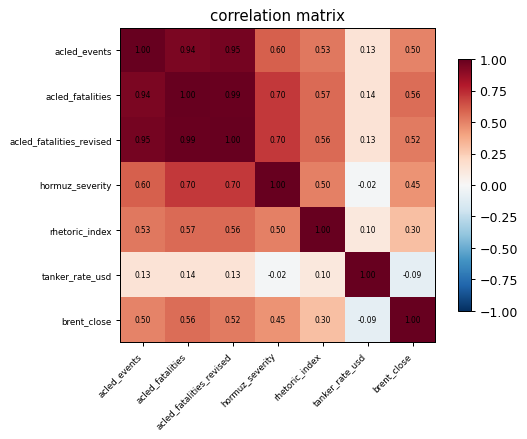

In [9]:
corr_cols = DRIVERS + [TARGET]
corr = df[corr_cols].corr()
print(corr.round(3).to_string())
corr.to_csv(f"{REPORTS}/correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=7)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, shrink=.8)
ax.set_title("correlation matrix")
plt.tight_layout()

Multicollinearity — VIF

Required for any candidate set larger than three. A VIF above 5 means the
driver is largely reconstructible from the others and its coefficient cannot be
read on its own.

                 feature    vif
acled_fatalities_revised 59.151
        acled_fatalities 44.963
            acled_events 12.326
         hormuz_severity  2.384
          rhetoric_index  1.531
         tanker_rate_usd  1.054

above 5, so collinear with the rest of the set:
  acled_fatalities_revised     59.151
  acled_fatalities             44.963
  acled_events                 12.326
only one of any collinear pair should enter a model.


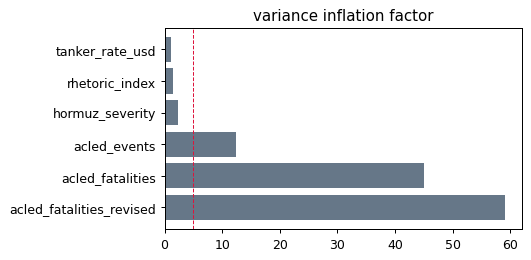

In [11]:
from src.stats.diagnostics import vif_table

vif = vif_table(df[DRIVERS])
print(vif.to_string(index=False))
vif.to_csv(f"{REPORTS}/vif.csv", index=False)

high = vif[vif["vif"] > 5]
print()
if len(high):
    print("above 5, so collinear with the rest of the set:")
    for _, r in high.iterrows():
        print(f"  {r['feature']:<28} {float(r['vif']):.3f}")
    print("only one of any collinear pair should enter a model.")
else:
    print("no driver exceeds a VIF of 5.")

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(vif["feature"], vif["vif"], color="#678")
ax.axvline(5, ls="--", c="crimson", lw=.8)
ax.set_title("variance inflation factor")
plt.tight_layout()

Top drivers

ranked by absolute correlation with brent_close
acled_fatalities            0.5574
acled_fatalities_revised    0.5185
acled_events                0.4982
hormuz_severity             0.4513
rhetoric_index              0.3042
tanker_rate_usd            -0.0907


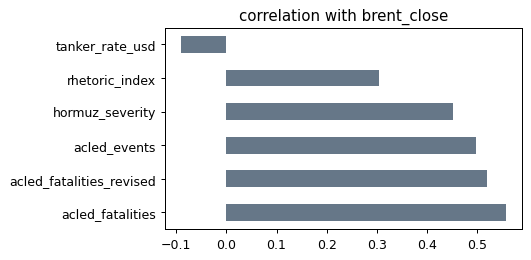

In [13]:
corrs = df[DRIVERS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("ranked by absolute correlation with", TARGET)
print(corrs.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 3))
corrs.plot(kind="barh", ax=ax, color="#678")
ax.set_title("correlation with " + TARGET)
plt.tight_layout()

Summary

In [15]:
lines = ["EDA SUMMARY", "=" * 70, ""]
lines.append("Top driver by absolute correlation: " + str(corrs.index[0]))
lines.append("Multicollinearity: " + str(len(high)) + " driver(s) above VIF 5")
lines.append("")
lines.append("Not supported by this data: any causal claim. Inventories, dollar")
lines.append("strength and demand are absent from the dataset, so the supportable")
lines.append("phrasing is that volatility rose during the conflict period, not")
lines.append("that the conflict caused the move.")

with open(f"{REPORTS}/feature_relationships.txt", "w") as fh:
    for line in lines:
        print(line, file=fh)
for line in lines:
    print(line)
print()
print("wrote", f"{REPORTS}/feature_relationships.txt")

EDA SUMMARY

Top driver by absolute correlation: acled_fatalities
Multicollinearity: 3 driver(s) above VIF 5

Not supported by this data: any causal claim. Inventories, dollar
strength and demand are absent from the dataset, so the supportable
phrasing is that volatility rose during the conflict period, not
that the conflict caused the move.

wrote results/reports/feature_relationships.txt
